### COMP 3610 Project - Modeling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from datetime import datetime
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, mean_absolute_error
from xgboost import XGBRegressor
import lightgbm as lgb

Since the data is structured and the value to be predicited is continuous, this is a linear regression problem. We decided to use the following linear regression models:
* XGBoost
* Random Forest
* Light GBM

In [2]:
df = pd.read_csv("SDV Synthetic Data V2.csv")

In [10]:
def timer(start = None):
    if not start:
        start = datetime.now()
        return start
    elif start:
        hour, temp_sec = divmod((datetime.now() - start).total_seconds(), 3600)
        mins, sec = divmod(temp_sec, 60)
        print(f'Time taken: {int(hour)} hours, {int(mins)} minutes and {round(sec,2)} seconds.')

In [3]:
X = df.drop(columns = ['Power Generated'], axis = 1)
y = df['Power Generated']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

In [6]:
xgb = XGBRegressor()
xgb.fit(X_train, y_train) # Training xgb model on X_train and y_train
y_predicted = xgb.predict(X_test) #Predicting y_test values based on model and X_test

In [7]:
xgb_mse = mean_squared_error(y_test, y_predicted)
xgb_rsq = r2_score(y_test, y_predicted)
xgb_mae = mean_absolute_error(y_test, y_predicted)

In [8]:
print(f"XGBoost Mean Square Error: {xgb_mse: .4f}\nXGBoost Mean Absolute Error: {xgb_mae: .4f}\nXGBoost R2 Score: {xgb_rsq: .4f}")

XGBoost Mean Square Error:  22906700.0000
XGBoost Mean Absolute Error:  2576.6516
XGBoost R2 Score:  0.7874


In [9]:
xgb_parameters = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 6, 9],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3],
    'reg_alpha': [0, 0.1, 1],   # L1 regularization
    'reg_lambda': [0, 0.1, 1],     # L2 regularization
}
xgb_grid = GridSearchCV(xgb, param_grid = xgb_parameters, cv = 3, scoring = 'r2')

In [10]:
start = timer(None)
xgb_grid.fit(X_train, y_train)
print(xgb_grid.best_params_)
timer(start)

{'gamma': 0, 'learning_rate': 0.05, 'max_depth': 6, 'min_child_weight': 5, 'n_estimators': 100, 'reg_alpha': 1, 'reg_lambda': 1}
Time taken: 0 hours, 40 minutes and 33.23 seconds.


In [11]:
xgb_parameters_2 = {
    'n_estimators': [50,100,150],
    'learning_rate': [0.025, 0.05, 0.1],
    'max_depth': [5,6,7],
    'min_child_weight': [4,5,6],
    'gamma': [0],
    'reg_alpha': [1],   # L1 regularization
    'reg_lambda': [1],     # L2 regularization
}
xgb_grid_2 = GridSearchCV(xgb, param_grid = xgb_parameters_2, cv = 3, scoring = 'r2')

In [12]:
start = timer(None)
xgb_grid_2.fit(X_train, y_train)
print(xgb_grid_2.best_params_)
timer(start)

{'gamma': 0, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 4, 'n_estimators': 150, 'reg_alpha': 1, 'reg_lambda': 1}
Time taken: 0 hours, 0 minutes and 31.39 seconds.


In [3]:
xgb_final = XGBRegressor(learning_rate = 0.05, max_depth = 5, n_estimators = 150, min_child_weight = 4, reg_alpha = 1, reg_lambda = 1, gamma=0)

In [12]:
xgb_final.fit(X_train, y_train) # Training xgb model on X_train and y_train
y_predicted_final = xgb_final.predict(X_test) #Predicting y_test values based on model and X_test

In [14]:
xgb_mse = mean_squared_error(y_test, y_predicted_final)
xgb_rsq = r2_score(y_test, y_predicted_final)
xgb_mae = mean_absolute_error(y_test, y_predicted_final)
print(f"XGBoost Mean Square Error: {xgb_mse: .4f}\nXGBoost Mean Absolute Error: {xgb_mae: .4f}\nXGBoost R2 Score: {xgb_rsq: .4f}")

XGBoost Mean Square Error:  20181614.0000
XGBoost Mean Absolute Error:  2384.2349
XGBoost R2 Score:  0.8127


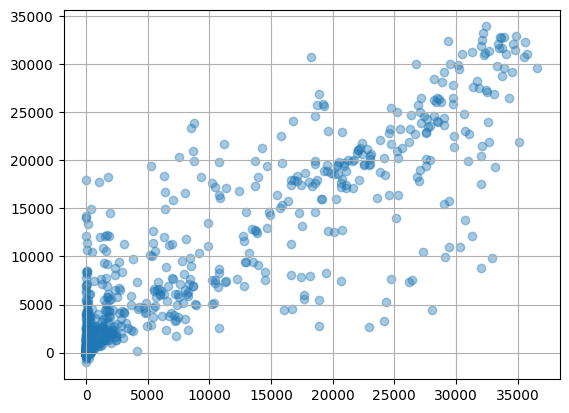

In [15]:
plt.scatter(y_test, y_predicted_final, alpha =0.4)
plt.grid(True)
plt.show()

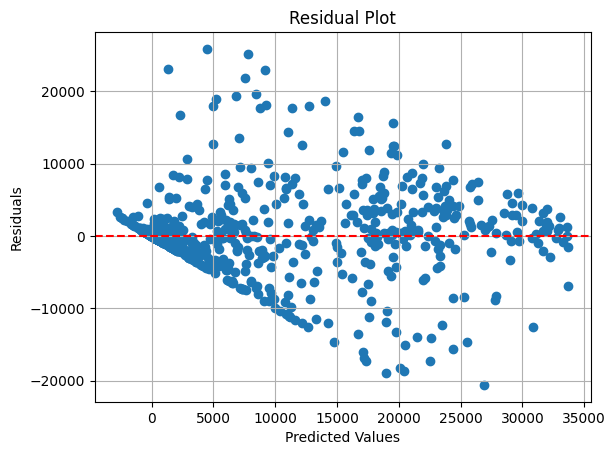

In [16]:
residuals = y_test - y_predicted
plt.scatter(y_predicted, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

In [20]:
xgb_final.save_model('xgb_model.json')  

### Random Forest

In [17]:
rfc = RandomForestRegressor()
rfc.fit(X_train, y_train)
y_pred_rfc = rfc.predict(X_test)

In [18]:
rfc_mae = mean_absolute_error(y_test, y_pred_rfc)
rfc_rs2 = r2_score(y_test, y_pred_rfc)
rfc_mse = mean_squared_error(y_test, y_pred_rfc)
print(f"Random Forest Mean Square Error: {rfc_mse: .4f}\nRandom Forest Mean Absolute Error: {rfc_mae: .4f}\nRandom Forest R2 Score: {rfc_rs2: .4f}")

Random Forest Mean Square Error:  22091471.9066
Random Forest Mean Absolute Error:  2458.9577
Random Forest R2 Score:  0.7950


In [19]:
rfr_parameters = {'n_estimators': [300, 500, 700],#, 700],
                  'min_samples_split': [3,5, 7],#,7],
                  'min_samples_leaf': [3,5,7],#,7],
                  'max_depth': [10, 18, 25],#, 25],
                  'max_features': ['sqrt', 'log2']}#, None]}
rfr_grid = GridSearchCV(rfc, param_grid = rfr_parameters, cv = 3, scoring = 'r2', n_jobs =1)

In [20]:
start = timer(None)
rfr_grid.fit(X_train, y_train)
print(rfr_grid.best_params_)
timer(start)

{'max_depth': 25, 'max_features': 'log2', 'min_samples_leaf': 3, 'min_samples_split': 3, 'n_estimators': 500}
Time taken: 0 hours, 19 minutes and 40.57 seconds.


In [21]:
rfr_parameters_2 = {'n_estimators': [400,500,600],
                  'min_samples_split': [2,3,4],
                  'min_samples_leaf': [2,3,4],
                  'max_depth': [22, 25, 28],
                  'max_features': ['log2']}
rfr_grid_2 = GridSearchCV(rfc, param_grid = rfr_parameters_2, cv = 3, scoring = 'r2', n_jobs =1)

In [22]:
start = timer(None)
rfr_grid_2.fit(X_train, y_train)
print(rfr_grid_2.best_params_)
timer(start)

{'max_depth': 22, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 400}
Time taken: 0 hours, 11 minutes and 30.57 seconds.


In [23]:
rfr_final = RandomForestRegressor(max_depth =22, max_features = 'log2', min_samples_leaf =2, min_samples_split=2, n_estimators =400)
rfr_final.fit(X_train, y_train)
y_pred_final = rfr_final.predict(X_test)

In [24]:
rfc_mae = mean_absolute_error(y_test, y_pred_final)
rfc_rs2 = r2_score(y_test, y_pred_final)
rfc_mse = mean_squared_error(y_test, y_pred_final)
print(f"Random Forest Mean Square Error: {rfc_mse: .4f}\nRandom Forest Mean Absolute Error: {rfc_mae: .4f}\nRandom Forest R2 Score: {rfc_rs2: .4f}")

Random Forest Mean Square Error:  20991890.9703
Random Forest Mean Absolute Error:  2479.5350
Random Forest R2 Score:  0.8052


### Light Gradient Boosting Machine

In [4]:
X_train.columns = X_train.columns.str.replace(' ', '_')
X_test.columns = X_train.columns.str.replace(' ', '_')
model = lgb.LGBMRegressor()
model.fit(X_train,y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000190 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1939
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 12
[LightGBM] [Info] Start training from score 7414.706500


LGBMRegressor()

In [5]:
y_pred = model.predict(X_test)
lgb_mse = mean_squared_error(y_test, y_pred)
lgb_rsq = r2_score(y_test, y_pred)
lgb_mae = mean_absolute_error(y_test, y_pred)
print(f"LightGBM Mean Square Error: {lgb_mse: .4f}\nLightGBM Mean Absolute Error: {lgb_mae: .4f}\nLightGBM R2 Score: {lgb_rsq: .4f}")

LightGBM Mean Square Error:  31088133.5918
LightGBM Mean Absolute Error:  2865.9798
LightGBM R2 Score:  0.7645


In [27]:
param_grid = param_grid = {
    'num_leaves': [30, 50, 70],
    'max_depth': [-1, 10, 20],
    'learning_rate': [0.1, 0.05, 0.01],
    'n_estimators': [100, 200, 500],
    'min_child_samples': [10, 20, 30],
    'reg_alpha': [0, 1],  # L1 regularization
    'reg_lambda': [0, 1]  # L2 regularization
}

lgb_grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring='r2', cv=3, n_jobs=-1)

In [28]:
lgb_grid.fit(X_train,y_train)
print(lgb_grid.best_params_)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000365 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2538
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 11
[LightGBM] [Info] Start training from score 6652.189000
{'learning_rate': 0.01, 'max_depth': -1, 'min_child_samples': 10, 'n_estimators': 500, 'num_leaves': 30, 'reg_alpha': 0, 'reg_lambda': 1}


In [29]:
param_grid_2 = param_grid = {
    'num_leaves': [20, 30, 40],
    'max_depth': [-1],
    'learning_rate': [0.05, 0.1, 0.15],
    'n_estimators': [400, 500, 600],
    'min_child_samples': [5, 10, 15],
    'reg_alpha': [0],  # L1 regularization
    'reg_lambda': [1]}  # L2 regularization}
lgb_grid_2 = GridSearchCV(estimator=model, param_grid=param_grid_2, scoring='r2', cv=3, n_jobs=-1)

In [30]:
lgb_grid_2.fit(X_train,y_train)
print(lgb_grid_2.best_params_)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000283 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2538
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 11
[LightGBM] [Info] Start training from score 6652.189000
{'learning_rate': 0.05, 'max_depth': -1, 'min_child_samples': 10, 'n_estimators': 400, 'num_leaves': 20, 'reg_alpha': 0, 'reg_lambda': 1}


In [31]:
lgb_final = lgb.LGBMRegressor(learning_rate=0.05, min_child_samples = 10, n_estimators = 400, max_depth=-1, num_leaves = 20, reg_alpha = 0, reg_lambda = 1)

In [32]:
lgb_final.fit(X_train, y_train)
y_pred = lgb_final.predict(X_test)
lgb_mse = mean_squared_error(y_test, y_pred)
lgb_rsq = r2_score(y_test, y_pred)
lgb_mae = mean_absolute_error(y_test, y_pred)
print(f"LightGBM Mean Square Error: {lgb_mse: .4f}\nLightGBM Mean Absolute Error: {lgb_mae: .4f}\nLightGBM R2 Score: {lgb_rsq: .4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000276 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2538
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 11
[LightGBM] [Info] Start training from score 6652.189000
LightGBM Mean Square Error:  21055100.5819
LightGBM Mean Absolute Error:  2431.6418
LightGBM R2 Score:  0.8046


In [6]:
models = ['XGBoost', 'Random Forest', 'Light GBM']
r2_before = [0.7874, 0.7950, 0.7645]
r2_after = [0.8127, 0.8052, 0.8046]
df = pd.DataFrame({'Model': models * 2, 'R2 Score': r2_before + r2_after, 'Tuning': ['Before'] * 3 + ['After'] * 3})

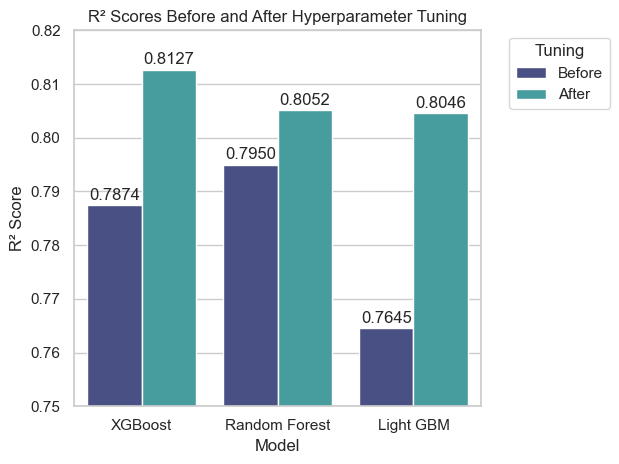

In [13]:
sns.set(style='whitegrid')
sns.barplot(x='Model', y='R2 Score', hue='Tuning', data=df, palette='mako')
plt.title('R² Scores Before and After Hyperparameter Tuning')
plt.ylim(0.75, 0.82)
plt.ylabel('R² Score')
plt.xlabel('Model')
for index, row in df.iterrows():
    plt.text(
        x=index % 3 - 0.2 + 0.4 * (index // 3), 
        y=row['R2 Score'] + 0.001, 
        s=f"{row['R2 Score']:.4f}", 
        ha='center'
    )
plt.legend(title='Tuning', bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.tight_layout()
plt.show()

Predicting Power Generated over the Next 12 Months

In [59]:
df = pd.read_csv('12_month_forecast.csv')

,datetime,Is Daylight,Distance to Solar Noon,Average Temperature (Day),Average Wind Direction (Day),Relative Humidity,Average Wind Speed (Period),Average Barometric Pressure (Period),Sky Cover,day_of_year_sin,day_of_year_cos,hour_sin,hour_cos
0,2025-05-01 00:00:00,1.0,0.750328,78.333333,-0.001642,92.333333,0.000000,29.0,0.802057,0.871706,-0.490029,0.258819,0.965926
1,2025-05-01 03:00:00,1.0,0.249362,89.333333,97.573864,58.666667,13.333333,29.0,1.866382,0.871706,-0.490029,0.866025,0.500000
2,2025-05-01 06:00:00,0.0,0.466626,80.000000,59.991876,84.666667,10.000000,29.0,0.861830,0.871706,-0.490029,0.965926,-0.258819
3,2025-05-01 09:00:00,0.0,0.916130,78.333333,29.970231,89.000000,5.333333,29.0,1.001236,0.871706,-0.490029,0.500000,-0.866025
4,2025-05-01 12:00:00,0.0,0.667953,78.666667,30.001422,86.000000,4.333333,29.0,0.434001,0.871706,-0.490029,-0.258819,-0.965926


In [60]:
date_columns = ['datetime']
date_cols = df[date_columns].copy()
df.drop(columns = date_columns, axis = 1, inplace = True)

In [64]:
#Reordering columns
expected_columns = [
    'Is Daylight',
    'Distance to Solar Noon',
    'Average Temperature (Day)',
    'Average Wind Direction (Day)',
    'Sky Cover',  # Move this here
    'Relative Humidity',
    'Average Wind Speed (Period)',
    'Average Barometric Pressure (Period)',
    'day_of_year_sin',
    'day_of_year_cos',
    'hour_sin',
    'hour_cos'
]

df = df[expected_columns]

In [ ]:
power_gen = xgb_final.predict(df)
df['Power Generated'] = power_gen
df = pd.concat([date_cols, df], axis = 1)
df.to_csv('predicted_year_mhm.csv', index = False, encoding = 'utf-8')